# Семинар 2. Исследование методов линейной регрессии

#### Критерий оценивания:
#### Пункт 14: максимум 0,5 балла
#### Пункт 15: максимум 0,5 балла

#### Итого за работу: максимум 1 балл
#### P.S. пункты 14 и 15 без пунктов 1-13 не засчитываются, ответы на вопросы из ИИ не засчитываются

1. Загрузите датасет и выведите на экран первые несколько строк

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

DATA_PATH = 'auto_dataset.csv'
TARGET = 'price'

data = pd.read_csv(DATA_PATH)

display(data.head())
print('Размер датасета:', data.shape)

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


Размер датасета: (1000, 10)


2. Разбейте выборку на признаки и ответы. Закодируйте категориальные признаки.

In [2]:
X = data.drop(columns=[TARGET]).copy()
y = data[TARGET].astype(float).copy()

cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=float)

print('Количество признаков после кодирования:', X.shape[1])
display(X.head())

Количество признаков после кодирования: 204


,powerPS,kilometer,autoAgeMonths,brand_audi,brand_bmw,brand_chevrolet,brand_chrysler,brand_citroen,brand_dacia,brand_daewoo,...,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,gearbox_manuell,fuelType_benzin,fuelType_diesel,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein
0,75,150000,177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,69,90000,93,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,102,150000,246,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,109,150000,140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,105,150000,136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


3. Разбейте датасет на train val test в отношении 8:1:1

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

X_train.insert(0, 'bias', 1.0)
X_val.insert(0, 'bias', 1.0)
X_test.insert(0, 'bias', 1.0)

y_train = y_train.reset_index(drop=True).to_numpy(dtype=float)
y_val = y_val.reset_index(drop=True).to_numpy(dtype=float)
y_test = y_test.reset_index(drop=True).to_numpy(dtype=float)

print('Train:', X_train.shape, y_train.shape)
print('Val:  ', X_val.shape, y_val.shape)
print('Test: ', X_test.shape, y_test.shape)

Train: (800, 205) (800,)
Val:   (100, 205) (100,)
Test:  (100, 205) (100,)


4. Исследуйте VGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

In [4]:
def predict(X, w):
    return np.asarray(X, dtype=np.float64) @ w


def time_decay_lr(lam, k, s0=1.0, p=0.5):
    return lam * (s0 / (s0 + k)) ** p


def get_eta(step, k, decay=False, s0=1.0, p=0.5):
    return time_decay_lr(step, k, s0, p) if decay else step


def make_result(step, w, n_iter, diverged=False):
    if diverged or not np.all(np.isfinite(w)):
        return {
            'step': step,
            'w': w,
            'n_iter': n_iter,
            'loss_train': np.inf,
            'loss_val': np.inf,
            'r2_train': -np.inf,
            'diverged': True
        }

    with np.errstate(over='ignore', invalid='ignore'):
        y_train_pred = predict(X_train, w)
        y_val_pred = predict(X_val, w)

    if not np.all(np.isfinite(y_train_pred)) or not np.all(np.isfinite(y_val_pred)):
        return {
            'step': step,
            'w': w,
            'n_iter': n_iter,
            'loss_train': np.inf,
            'loss_val': np.inf,
            'r2_train': -np.inf,
            'diverged': True
        }

    return {
        'step': step,
        'w': w,
        'n_iter': n_iter,
        'loss_train': mean_squared_error(y_train, y_train_pred),
        'loss_val': mean_squared_error(y_val, y_val_pred),
        'r2_train': r2_score(y_train, y_train_pred),
        'diverged': False
    }


def results_table(results):
    return pd.DataFrame([
        {
            'step': result['step'],
            'Loss_train': result['loss_train'],
            'R2_train': result['r2_train'],
            'Loss_val': result['loss_val'],
            'n_iter': result['n_iter'],
            'status': 'diverged' if result['diverged'] else 'ok'
        }
        for result in results
    ])


def choose_best_and_test(results):
    valid_results = [result for result in results if not result['diverged']]

    if not valid_results:
        raise ValueError('Все значения шага привели к расходимости.')

    best = min(valid_results, key=lambda result: result['loss_val']).copy()

    y_test_pred = predict(X_test, best['w'])

    best['loss_test'] = mean_squared_error(y_test, y_test_pred)
    best['r2_test'] = r2_score(y_test, y_test_pred)

    return best


def vanilla_gd(X, y, step, n_iters=1000, decay=False, s0=1.0, p=0.5, tol=1e-10):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n, d = X.shape
    w = np.zeros(d)

    for k in range(n_iters):
        with np.errstate(over='ignore', invalid='ignore'):
            grad = (2 / n) * X.T @ (X @ w - y)

        if not np.all(np.isfinite(grad)):
            return w, k, True

        eta = get_eta(step, k, decay, s0, p)

        with np.errstate(over='ignore', invalid='ignore'):
            w_new = w - eta * grad

        if not np.all(np.isfinite(w_new)):
            return w, k, True

        if np.linalg.norm(w_new - w) < tol:
            return w_new, k + 1, False

        w = w_new

    return w, n_iters, False


STEPS = np.logspace(-5, 0, 6)
N_ITERS = 5000

vgd_constant_results = []

for eta in STEPS:
    w, n_iter, diverged = vanilla_gd(
        X_train, y_train, step=eta,
        n_iters=N_ITERS, decay=False
    )

    vgd_constant_results.append(
        make_result(eta, w, n_iter, diverged)
    )

display(results_table(vgd_constant_results))

best_vgd_constant = choose_best_and_test(vgd_constant_results)

print(f"Лучший постоянный шаг eta: {best_vgd_constant['step']:.0e}")
print(f"Loss_train: {best_vgd_constant['loss_train']:.4f}")
print(f"Loss_val:   {best_vgd_constant['loss_val']:.4f}")
print(f"Loss_test:  {best_vgd_constant['loss_test']:.4f}")
print(f"R^2_train:  {best_vgd_constant['r2_train']:.6f}")
print(f"R^2_test:   {best_vgd_constant['r2_test']:.6f}")
print(f"Число итераций: {best_vgd_constant['n_iter']}")

,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,8.350049e+07,-0.371955,8.006857e+07,5000,ok
1,0.00010,2.222627e+07,0.634811,2.032179e+07,5000,ok
2,0.00100,1.271979e+07,0.791007,1.689811e+07,5000,ok
3,0.01000,1.211564e+07,0.800934,1.755366e+07,5000,ok
4,0.10000,1.202832e+07,0.802369,1.839746e+07,5000,ok
5,1.00000,inf,-inf,inf,377,diverged


Лучший постоянный шаг eta: 1e-03
Loss_train: 12719793.6695
Loss_val:   16898112.5529
Loss_test:  28780464.2800
R^2_train:  0.791007
R^2_test:   0.587303
Число итераций: 5000


5. Исследуйте VGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

In [5]:
vgd_decay_results = []

for lam in STEPS:
    w, n_iter, diverged = vanilla_gd(
        X_train, y_train,
        step=lam,
        n_iters=N_ITERS,
        decay=True
    )

    vgd_decay_results.append(
        make_result(lam, w, n_iter, diverged)
    )

display(results_table(vgd_decay_results))

best_vgd_decay = choose_best_and_test(vgd_decay_results)

print(f"Лучший lambda: {best_vgd_decay['step']:.0e}")
print(f"Функция шага: eta_k = {best_vgd_decay['step']:.0e} * (1 / (1 + k))^0.5")
print(f"Loss_train: {best_vgd_decay['loss_train']:.4f}")
print(f"Loss_val:   {best_vgd_decay['loss_val']:.4f}")
print(f"Loss_test:  {best_vgd_decay['loss_test']:.4f}")
print(f"R^2_train:  {best_vgd_decay['r2_train']:.6f}")
print(f"R^2_test:   {best_vgd_decay['r2_test']:.6f}")
print(f"Число итераций: {best_vgd_decay['n_iter']}")

,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,1.083963e+08,-0.781005,1.062791e+08,5000,ok
1,0.00010,1.009417e+08,-0.658523,9.838721e+07,5000,ok
2,0.00100,5.610670e+07,0.078139,5.199630e+07,5000,ok
3,0.01000,1.360320e+07,0.776493,1.529679e+07,5000,ok
4,0.10000,1.241402e+07,0.796031,1.742411e+07,5000,ok
5,1.00000,1.203356e+07,0.802283,1.797560e+07,5000,ok


Лучший lambda: 1e-02
Функция шага: eta_k = 1e-02 * (1 / (1 + k))^0.5
Loss_train: 13603201.6691
Loss_val:   15296791.7813
Loss_test:  30688544.5404
R^2_train:  0.776493
R^2_test:   0.559942
Число итераций: 5000


6. Исследуйте SGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

In [6]:
def stochastic_gd(X, y, step, n_iters=1000, batch_size=1, decay=False, s0=1.0, p=0.5, random_state=42):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n, d = X.shape
    w = np.zeros(d)

    rng = np.random.default_rng(random_state)

    for k in range(n_iters):
        batch_idx = rng.choice(n, size=min(batch_size, n), replace=False)

        X_batch = X[batch_idx]
        y_batch = y[batch_idx]

        grad = (2 / len(batch_idx)) * X_batch.T @ (X_batch @ w - y_batch)
        eta = get_eta(step, k, decay, s0, p)

        w_new = w - eta * grad

        if not np.all(np.isfinite(w_new)):
            return w, k

        w = w_new

    return w, n_iters


sgd_constant_results = []

for eta in STEPS:
    w, n_iter = stochastic_gd(
        X_train, y_train, step=eta,
        n_iters=N_ITERS, batch_size=1,
        decay=False, random_state=42
    )

    sgd_constant_results.append(
        make_result(eta, w, n_iter)
    )

display(results_table(sgd_constant_results))

best_sgd_constant = choose_best_and_test(sgd_constant_results)

print(f"Лучший постоянный шаг eta: {best_sgd_constant['step']:.0e}")
print(f"Loss_train: {best_sgd_constant['loss_train']:.4f}")
print(f"Loss_val:   {best_sgd_constant['loss_val']:.4f}")
print(f"Loss_test:  {best_sgd_constant['loss_test']:.4f}")
print(f"R^2_train:  {best_sgd_constant['r2_train']:.6f}")
print(f"R^2_test:   {best_sgd_constant['r2_test']:.6f}")
print(f"Число итераций: {best_sgd_constant['n_iter']}")

/tmp/ipykernel_11530/4272322326.py:16: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(batch_idx)) * X_batch.T @ (X_batch @ w - y_batch)
/tmp/ipykernel_11530/4272322326.py:16: RuntimeWarning: invalid value encountered in matmul
  grad = (2 / len(batch_idx)) * X_batch.T @ (X_batch @ w - y_batch)


,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,8.307610e+07,-3.649818e-01,7.802197e+07,5000,ok
1,0.00010,2.133809e+07,6.494044e-01,1.869156e+07,5000,ok
2,0.00100,9.103824e+10,-1.494804e+03,9.105593e+07,5000,ok
3,0.01000,1.910170e+91,-3.138504e+83,1.806918e+90,5000,ok
4,0.10000,inf,-inf,inf,2264,diverged
5,1.00000,inf,-inf,inf,373,diverged


Лучший постоянный шаг eta: 1e-04
Loss_train: 21338094.4927
Loss_val:   18691558.2346
Loss_test:  39069585.9149
R^2_train:  0.649404
R^2_test:   0.439762
Число итераций: 5000


7. Исследуйте SGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

In [7]:
sgd_decay_results = []

for lam in STEPS:
    w, n_iter = stochastic_gd(
        X_train, y_train, step=lam,
        n_iters=N_ITERS, batch_size=1,
        decay=True, random_state=42
    )

    sgd_decay_results.append(
        make_result(lam, w, n_iter)
    )

display(results_table(sgd_decay_results))

best_sgd_decay = choose_best_and_test(sgd_decay_results)

print(f"Лучший lambda: {best_sgd_decay['step']:.0e}")
print(f"Функция шага: eta_k = {best_sgd_decay['step']:.0e} * (1 / (1 + k))^0.5")
print(f"Loss_train: {best_sgd_decay['loss_train']:.4f}")
print(f"Loss_val:   {best_sgd_decay['loss_val']:.4f}")
print(f"Loss_test:  {best_sgd_decay['loss_test']:.4f}")
print(f"R^2_train:  {best_sgd_decay['r2_train']:.6f}")
print(f"R^2_test:   {best_sgd_decay['r2_test']:.6f}")
print(f"Число итераций: {best_sgd_decay['n_iter']}")

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)


,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,1.084201e+08,-7.813969e-01,1.062357e+08,5000,ok
1,0.00010,1.011486e+08,-6.619222e-01,9.798283e+07,5000,ok
2,0.00100,5.652665e+07,7.123885e-02,5.006515e+07,5000,ok
3,0.01000,1.420092e+07,7.666718e-01,1.591735e+07,5000,ok
4,0.10000,8.451724e+24,-1.388660e+17,2.062592e+22,5000,ok
5,1.00000,inf,-inf,inf,5000,ok


Лучший lambda: 1e-02
Функция шага: eta_k = 1e-02 * (1 / (1 + k))^0.5
Loss_train: 14200920.9196
Loss_val:   15917351.3410
Loss_test:  31340072.3714
R^2_train:  0.766672
R^2_test:   0.550599
Число итераций: 5000


8. Исследуйте SAG с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

In [8]:
def sag_descent(X, y, step, n_iters=1000, decay=False, s0=1.0, p=0.5, random_state=42):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n, d = X.shape
    w = np.zeros(d)

    grad_coeff_memory = np.zeros(n)
    avg_grad = np.zeros(d)

    rng = np.random.default_rng(random_state)

    for k in range(n_iters):
        j = rng.integers(0, n)

        xj = X[j]
        yj = y[j]

        new_coeff = 2 * (xj @ w - yj)
        old_coeff = grad_coeff_memory[j]

        avg_grad = avg_grad + ((new_coeff - old_coeff) / n) * xj
        grad_coeff_memory[j] = new_coeff

        eta = get_eta(step, k, decay, s0, p)

        w_new = w - eta * avg_grad

        if not np.all(np.isfinite(w_new)):
            return w, k

        w = w_new

    return w, n_iters


sag_constant_results = []

for eta in STEPS:
    w, n_iter = sag_descent(
        X_train, y_train, step=eta,
        n_iters=N_ITERS, decay=False,
        random_state=42
    )

    sag_constant_results.append(
        make_result(eta, w, n_iter)
    )

display(results_table(sag_constant_results))

best_sag_constant = choose_best_and_test(sag_constant_results)

print(f"Лучший постоянный шаг eta: {best_sag_constant['step']:.0e}")
print(f"Loss_train: {best_sag_constant['loss_train']:.4f}")
print(f"Loss_val:   {best_sag_constant['loss_val']:.4f}")
print(f"Loss_test:  {best_sag_constant['loss_test']:.4f}")
print(f"R^2_train:  {best_sag_constant['r2_train']:.6f}")
print(f"R^2_test:   {best_sag_constant['r2_test']:.6f}")
print(f"Число итераций: {best_sag_constant['n_iter']}")

/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,8.702700e+07,-4.298971e-01,8.343458e+07,5000,ok
1,0.00010,2.318709e+07,6.190245e-01,2.052345e+07,5000,ok
2,0.00100,6.842410e+10,-1.123242e+03,2.251833e+08,5000,ok
3,0.01000,5.645319e+24,-9.275542e+16,7.069373e+22,5000,ok
4,0.10000,5.689918e+73,-9.348820e+65,2.728799e+72,5000,ok
5,1.00000,6.808925e+232,-1.118740e+225,6.874047e+232,5000,ok


Лучший постоянный шаг eta: 1e-04
Loss_train: 23187090.7597
Loss_val:   20523451.8624
Loss_test:  44122181.2007
R^2_train:  0.619025
R^2_test:   0.367310
Число итераций: 5000


9. Исследуйте SAG с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

In [9]:
sag_decay_results = []

for lam in STEPS:
    w, n_iter = sag_descent(
        X_train, y_train, step=lam,
        n_iters=N_ITERS, decay=True,
        random_state=42
    )

    sag_decay_results.append(
        make_result(lam, w, n_iter)
    )

display(results_table(sag_decay_results))

best_sag_decay = choose_best_and_test(sag_decay_results)

print(f"Лучший lambda: {best_sag_decay['step']:.0e}")
print(f"Функция шага: eta_k = {best_sag_decay['step']:.0e} * (1 / (1 + k))^0.5")
print(f"Loss_train: {best_sag_decay['loss_train']:.4f}")
print(f"Loss_val:   {best_sag_decay['loss_val']:.4f}")
print(f"Loss_test:  {best_sag_decay['loss_test']:.4f}")
print(f"R^2_train:  {best_sag_decay['r2_train']:.6f}")
print(f"R^2_test:   {best_sag_decay['r2_test']:.6f}")
print(f"Число итераций: {best_sag_decay['n_iter']}")

,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,1.087226e+08,-7.863662e-01,1.066110e+08,5000,ok
1,0.00010,1.039065e+08,-7.072358e-01,1.013846e+08,5000,ok
2,0.00100,6.862378e+07,-1.275231e-01,6.370512e+07,5000,ok
3,0.01000,1.425893e+07,7.657187e-01,1.463025e+07,5000,ok
4,0.10000,5.119208e+13,-8.411104e+05,9.708129e+10,5000,ok
5,1.00000,2.416980e+36,-3.971219e+28,3.188516e+34,5000,ok


Лучший lambda: 1e-02
Функция шага: eta_k = 1e-02 * (1 / (1 + k))^0.5
Loss_train: 14258928.0310
Loss_val:   14630246.5213
Loss_test:  32976608.7162
R^2_train:  0.765719
R^2_test:   0.527132
Число итераций: 5000


10. Исследуйте Momentum с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

In [10]:
def momentum_descent(X, y, step, n_iters=1000, alpha=0.9, decay=False, s0=1.0, p=0.5, tol=1e-10):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n, d = X.shape

    w = np.zeros(d)
    h = np.zeros(d)

    for k in range(n_iters):
        grad = (2 / n) * X.T @ (X @ w - y)
        eta = get_eta(step, k, decay, s0, p)

        h = alpha * h + eta * grad
        w_new = w - h

        if not np.all(np.isfinite(w_new)):
            return w, k

        if np.linalg.norm(w_new - w) < tol:
            return w_new, k + 1

        w = w_new

    return w, n_iters


momentum_constant_results = []

for eta in STEPS:
    w, n_iter = momentum_descent(
        X_train, y_train, step=eta,
        n_iters=N_ITERS, alpha=0.9,
        decay=False
    )

    momentum_constant_results.append(
        make_result(eta, w, n_iter)
    )

display(results_table(momentum_constant_results))

best_momentum_constant = choose_best_and_test(momentum_constant_results)

print(f"Лучший постоянный шаг eta: {best_momentum_constant['step']:.0e}")
print(f"Loss_train: {best_momentum_constant['loss_train']:.4f}")
print(f"Loss_val:   {best_momentum_constant['loss_val']:.4f}")
print(f"Loss_test:  {best_momentum_constant['loss_test']:.4f}")
print(f"R^2_train:  {best_momentum_constant['r2_train']:.6f}")
print(f"R^2_test:   {best_momentum_constant['r2_test']:.6f}")
print(f"Число итераций: {best_momentum_constant['n_iter']}")

/tmp/ipykernel_11530/3642496178.py:11: RuntimeWarning: overflow encountered in matmul
  grad = (2 / n) * X.T @ (X @ w - y)
/tmp/ipykernel_11530/3642496178.py:11: RuntimeWarning: invalid value encountered in matmul
  grad = (2 / n) * X.T @ (X @ w - y)


,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,2.222412e+07,0.634847,2.031828e+07,5000,ok
1,0.00010,1.271994e+07,0.791005,1.689978e+07,5000,ok
2,0.00100,1.211564e+07,0.800934,1.755372e+07,5000,ok
3,0.01000,1.202832e+07,0.802369,1.839784e+07,5000,ok
4,0.10000,1.202827e+07,0.802369,1.843005e+07,4940,ok
5,1.00000,inf,-inf,inf,418,diverged


Лучший постоянный шаг eta: 1e-04
Loss_train: 12719939.0584
Loss_val:   16899777.9580
Loss_test:  28779370.1295
R^2_train:  0.791005
R^2_test:   0.587318
Число итераций: 5000


## Проверка на переобучение лучшей модели

In [11]:
def momentum_history(
    X, y, X_val, y_val, step,
    n_iters=5000, alpha=0.9, tol=1e-10
):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    X_val = np.asarray(X_val, dtype=np.float64)
    y_val = np.asarray(y_val, dtype=np.float64)

    n, d = X.shape

    w = np.zeros(d)
    h = np.zeros(d)

    train_history = []
    val_history = []

    for k in range(n_iters):
        grad = (2 / n) * X.T @ (X @ w - y)

        h = alpha * h + step * grad
        w_new = w - h

        if not np.all(np.isfinite(w_new)):
            break

        train_history.append(
            mean_squared_error(y, X @ w_new)
        )

        val_history.append(
            mean_squared_error(y_val, X_val @ w_new)
        )

        if np.linalg.norm(w_new - w) < tol:
            w = w_new
            break

        w = w_new

    return w, train_history, val_history

In [12]:
best_eta = best_momentum_constant['step']

w_history, train_history, val_history = momentum_history(
    X_train,
    y_train,
    X_val,
    y_val,
    step=best_eta,
    n_iters=N_ITERS,
    alpha=0.9
)

print(f"Лучший eta: {best_eta:.0e}")
print(f"Количество выполненных итераций: {len(train_history)}")

Лучший eta: 1e-04
Количество выполненных итераций: 5000


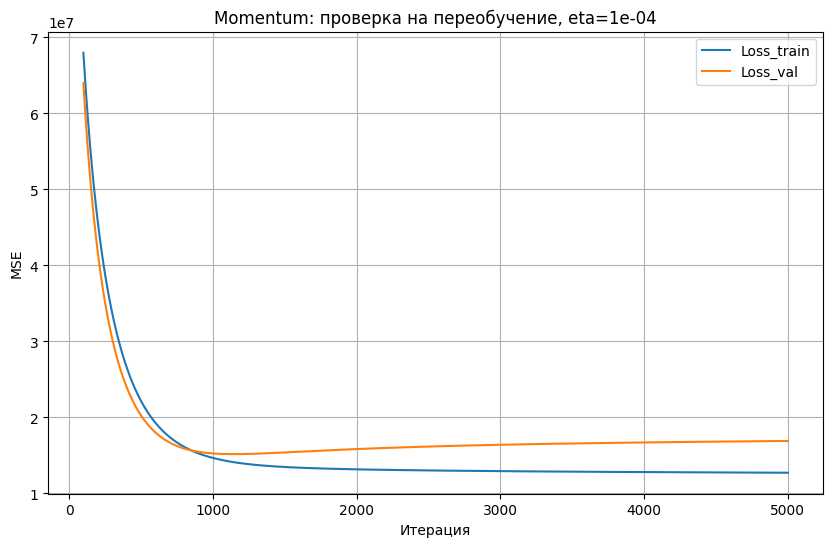

In [13]:
start_iter = 100

plt.figure(figsize=(10, 6))

plt.plot(
    range(start_iter, len(train_history) + 1),
    train_history[start_iter - 1:],
    label='Loss_train'
)

plt.plot(
    range(start_iter, len(val_history) + 1),
    val_history[start_iter - 1:],
    label='Loss_val'
)

plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title(
    f'Momentum: проверка на переобучение, eta={best_eta:.0e}'
)
plt.legend()
plt.grid(True)

plt.show()

11. Исследуйте Momentum с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

In [14]:
momentum_decay_results = []

for lam in STEPS:
    w, n_iter = momentum_descent(
        X_train, y_train, step=lam,
        n_iters=N_ITERS, alpha=0.9,
        decay=True
    )

    momentum_decay_results.append(
        make_result(lam, w, n_iter)
    )

display(results_table(momentum_decay_results))

best_momentum_decay = choose_best_and_test(momentum_decay_results)

print(f"Лучший lambda: {best_momentum_decay['step']:.0e}")
print(f"Функция шага: eta_k = {best_momentum_decay['step']:.0e} * (1 / (1 + k))^0.5")
print(f"Loss_train: {best_momentum_decay['loss_train']:.4f}")
print(f"Loss_val:   {best_momentum_decay['loss_val']:.4f}")
print(f"Loss_test:  {best_momentum_decay['loss_test']:.4f}")
print(f"R^2_train:  {best_momentum_decay['r2_train']:.6f}")
print(f"R^2_test:   {best_momentum_decay['r2_test']:.6f}")
print(f"Число итераций: {best_momentum_decay['n_iter']}")

,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,1.009473e+08,-0.658614,9.839301e+07,5000,ok
1,0.00010,5.608655e+07,0.078470,5.197384e+07,5000,ok
2,0.00100,1.359155e+07,0.776684,1.529971e+07,5000,ok
3,0.01000,1.241376e+07,0.796036,1.742671e+07,5000,ok
4,0.10000,1.203343e+07,0.802285,1.797834e+07,5000,ok
5,1.00000,1.202827e+07,0.802369,1.842984e+07,5000,ok


Лучший lambda: 1e-03
Функция шага: eta_k = 1e-03 * (1 / (1 + k))^0.5
Loss_train: 13591553.6495
Loss_val:   15299712.1309
Loss_test:  30657018.5131
R^2_train:  0.776684
R^2_test:   0.560394
Число итераций: 5000


12. Исследуйте Adam с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

In [15]:
def adam_descent(X, y, step, n_iters=1000, beta1=0.9, beta2=0.999, eps=1e-8, decay=False, s0=1.0, p=0.5, tol=1e-10):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n, d = X.shape

    w = np.zeros(d)
    m = np.zeros(d)
    v = np.zeros(d)

    for k in range(n_iters):
        grad = (2 / n) * X.T @ (X @ w - y)
        eta = get_eta(step, k, decay, s0, p)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad ** 2

        m_hat = m / (1 - beta1 ** (k + 1))
        v_hat = v / (1 - beta2 ** (k + 1))

        w_new = w - eta * m_hat / (np.sqrt(v_hat) + eps)

        if not np.all(np.isfinite(w_new)):
            return w, k

        if np.linalg.norm(w_new - w) < tol:
            return w_new, k + 1

        w = w_new

    return w, n_iters


adam_constant_results = []

for eta in STEPS:
    w, n_iter = adam_descent(
        X_train, y_train, step=eta,
        n_iters=N_ITERS, decay=False
    )

    adam_constant_results.append(
        make_result(eta, w, n_iter)
    )

display(results_table(adam_constant_results))

best_adam_constant = choose_best_and_test(adam_constant_results)

print(f"Лучший постоянный шаг eta: {best_adam_constant['step']:.0e}")
print(f"Loss_train: {best_adam_constant['loss_train']:.4f}")
print(f"Loss_val:   {best_adam_constant['loss_val']:.4f}")
print(f"Loss_test:  {best_adam_constant['loss_test']:.4f}")
print(f"R^2_train:  {best_adam_constant['r2_train']:.6f}")
print(f"R^2_test:   {best_adam_constant['r2_test']:.6f}")
print(f"Число итераций: {best_adam_constant['n_iter']}")

,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,1.092669e+08,-0.795309,1.072018e+08,5000,ok
1,0.00010,1.091859e+08,-0.793978,1.071074e+08,5000,ok
2,0.00100,1.083842e+08,-0.780806,1.061710e+08,5000,ok
3,0.01000,1.011326e+08,-0.661659,9.767378e+07,5000,ok
4,0.10000,6.848522e+07,-0.125246,6.188237e+07,5000,ok
5,1.00000,1.909599e+07,0.686243,2.293881e+07,5000,ok


Лучший постоянный шаг eta: 1e+00
Loss_train: 19095992.2535
Loss_val:   22938809.2158
Loss_test:  43212806.2714
R^2_train:  0.686243
R^2_test:   0.380350
Число итераций: 5000


13. Исследуйте Adam с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

In [16]:
adam_decay_results = []

for lam in STEPS:
    w, n_iter = adam_descent(
        X_train, y_train, step=lam,
        n_iters=N_ITERS, decay=True
    )

    adam_decay_results.append(
        make_result(lam, w, n_iter)
    )

display(results_table(adam_decay_results))

best_adam_decay = choose_best_and_test(adam_decay_results)

print(f"Лучший lambda: {best_adam_decay['step']:.0e}")
print(f"Функция шага: eta_k = {best_adam_decay['step']:.0e} * (1 / (1 + k))^0.5")
print(f"Loss_train: {best_adam_decay['loss_train']:.4f}")
print(f"Loss_val:   {best_adam_decay['loss_val']:.4f}")
print(f"Loss_test:  {best_adam_decay['loss_test']:.4f}")
print(f"R^2_train:  {best_adam_decay['r2_train']:.6f}")
print(f"R^2_test:   {best_adam_decay['r2_test']:.6f}")
print(f"Число итераций: {best_adam_decay['n_iter']}")

,step,Loss_train,R2_train,Loss_val,n_iter,status
0,0.00001,1.092756e+08,-0.795453,1.072120e+08,5000,ok
1,0.00010,1.092733e+08,-0.795416,1.072093e+08,5000,ok
2,0.00100,1.092507e+08,-0.795043,1.071829e+08,5000,ok
3,0.01000,1.090244e+08,-0.791325,1.069190e+08,5000,ok
4,0.10000,1.068216e+08,-0.755132,1.043448e+08,5000,ok
5,1.00000,8.986436e+07,-0.476516,8.443914e+07,5000,ok


Лучший lambda: 1e+00
Функция шага: eta_k = 1e+00 * (1 / (1 + k))^0.5
Loss_train: 89864357.5013
Loss_val:   84439140.2584
Loss_test:  119497873.3668
R^2_train:  -0.476516
R^2_test:   -0.713539
Число итераций: 5000


14. Постройте итоговую сравнительную таблицу со следующими столбцами:

1) название метода

2) значение лучшего шага (если n) или функция лучшего шага (если n(lyamda))

3) Loss_train

4) Loss_test

5) R^2 train

6) R^2 test

7) число итераций на test

In [17]:
def step_label(best, decay=False):
    if not decay:
        return f"eta = {best['step']:.0e}"

    return f"eta_k = {best['step']:.0e} * (1/(1+k))^0.5"


comparison = pd.DataFrame([
    {
        'Метод': 'VGD, постоянный шаг',
        'Лучший шаг': step_label(best_vgd_constant),
        'Loss_train': best_vgd_constant['loss_train'],
        'Loss_test': best_vgd_constant['loss_test'],
        'R2_train': best_vgd_constant['r2_train'],
        'R2_test': best_vgd_constant['r2_test'],
        'Итерации': best_vgd_constant['n_iter']
    },
    {
        'Метод': 'VGD, TimeDecayLR',
        'Лучший шаг': step_label(best_vgd_decay, decay=True),
        'Loss_train': best_vgd_decay['loss_train'],
        'Loss_test': best_vgd_decay['loss_test'],
        'R2_train': best_vgd_decay['r2_train'],
        'R2_test': best_vgd_decay['r2_test'],
        'Итерации': best_vgd_decay['n_iter']
    },
    {
        'Метод': 'SGD, постоянный шаг',
        'Лучший шаг': step_label(best_sgd_constant),
        'Loss_train': best_sgd_constant['loss_train'],
        'Loss_test': best_sgd_constant['loss_test'],
        'R2_train': best_sgd_constant['r2_train'],
        'R2_test': best_sgd_constant['r2_test'],
        'Итерации': best_sgd_constant['n_iter']
    },
    {
        'Метод': 'SGD, TimeDecayLR',
        'Лучший шаг': step_label(best_sgd_decay, decay=True),
        'Loss_train': best_sgd_decay['loss_train'],
        'Loss_test': best_sgd_decay['loss_test'],
        'R2_train': best_sgd_decay['r2_train'],
        'R2_test': best_sgd_decay['r2_test'],
        'Итерации': best_sgd_decay['n_iter']
    },
    {
        'Метод': 'SAG, постоянный шаг',
        'Лучший шаг': step_label(best_sag_constant),
        'Loss_train': best_sag_constant['loss_train'],
        'Loss_test': best_sag_constant['loss_test'],
        'R2_train': best_sag_constant['r2_train'],
        'R2_test': best_sag_constant['r2_test'],
        'Итерации': best_sag_constant['n_iter']
    },
    {
        'Метод': 'SAG, TimeDecayLR',
        'Лучший шаг': step_label(best_sag_decay, decay=True),
        'Loss_train': best_sag_decay['loss_train'],
        'Loss_test': best_sag_decay['loss_test'],
        'R2_train': best_sag_decay['r2_train'],
        'R2_test': best_sag_decay['r2_test'],
        'Итерации': best_sag_decay['n_iter']
    },
    {
        'Метод': 'Momentum, постоянный шаг',
        'Лучший шаг': step_label(best_momentum_constant),
        'Loss_train': best_momentum_constant['loss_train'],
        'Loss_test': best_momentum_constant['loss_test'],
        'R2_train': best_momentum_constant['r2_train'],
        'R2_test': best_momentum_constant['r2_test'],
        'Итерации': best_momentum_constant['n_iter']
    },
    {
        'Метод': 'Momentum, TimeDecayLR',
        'Лучший шаг': step_label(best_momentum_decay, decay=True),
        'Loss_train': best_momentum_decay['loss_train'],
        'Loss_test': best_momentum_decay['loss_test'],
        'R2_train': best_momentum_decay['r2_train'],
        'R2_test': best_momentum_decay['r2_test'],
        'Итерации': best_momentum_decay['n_iter']
    },
    {
        'Метод': 'Adam, постоянный шаг',
        'Лучший шаг': step_label(best_adam_constant),
        'Loss_train': best_adam_constant['loss_train'],
        'Loss_test': best_adam_constant['loss_test'],
        'R2_train': best_adam_constant['r2_train'],
        'R2_test': best_adam_constant['r2_test'],
        'Итерации': best_adam_constant['n_iter']
    },
    {
        'Метод': 'Adam, TimeDecayLR',
        'Лучший шаг': step_label(best_adam_decay, decay=True),
        'Loss_train': best_adam_decay['loss_train'],
        'Loss_test': best_adam_decay['loss_test'],
        'R2_train': best_adam_decay['r2_train'],
        'R2_test': best_adam_decay['r2_test'],
        'Итерации': best_adam_decay['n_iter']
    }
])

comparison = comparison.sort_values(
    ['Loss_test', 'R2_test'],
    ascending=[True, False]
).reset_index(drop=True)

display(comparison)

,Метод,Лучший шаг,Loss_train,Loss_test,R2_train,R2_test,Итерации
0,"Momentum, постоянный шаг",eta = 1e-04,1.271994e+07,2.877937e+07,0.791005,0.587318,5000
1,"VGD, постоянный шаг",eta = 1e-03,1.271979e+07,2.878046e+07,0.791007,0.587303,5000
2,"Momentum, TimeDecayLR",eta_k = 1e-03 * (1/(1+k))^0.5,1.359155e+07,3.065702e+07,0.776684,0.560394,5000
3,"VGD, TimeDecayLR",eta_k = 1e-02 * (1/(1+k))^0.5,1.360320e+07,3.068854e+07,0.776493,0.559942,5000
4,"SGD, TimeDecayLR",eta_k = 1e-02 * (1/(1+k))^0.5,1.420092e+07,3.134007e+07,0.766672,0.550599,5000
5,"SAG, TimeDecayLR",eta_k = 1e-02 * (1/(1+k))^0.5,1.425893e+07,3.297661e+07,0.765719,0.527132,5000
6,"SGD, постоянный шаг",eta = 1e-04,2.133809e+07,3.906959e+07,0.649404,0.439762,5000
7,"Adam, постоянный шаг",eta = 1e+00,1.909599e+07,4.321281e+07,0.686243,0.380350,5000
8,"SAG, постоянный шаг",eta = 1e-04,2.318709e+07,4.412218e+07,0.619025,0.367310,5000
9,"Adam, TimeDecayLR",eta_k = 1e+00 * (1/(1+k))^0.5,8.986436e+07,1.194979e+08,-0.476516,-0.713539,5000


15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

2) расскажите простыми словами суть R^2_train и R^2_test?

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?

In [18]:
best_overall = comparison.iloc[0]

print(f"Лучший метод: {best_overall['Метод']}")
print(f"Лучший шаг: {best_overall['Лучший шаг']}")
print(f"Loss_test: {best_overall['Loss_test']:.4f}")
print(f"R^2_test: {best_overall['R2_test']:.6f}")
print(f"Число итераций: {best_overall['Итерации']}")

Лучший метод: Momentum, постоянный шаг
Лучший шаг: eta = 1e-04
Loss_test: 28779370.1295
R^2_test: 0.587318
Число итераций: 5000


## Ответы на вопросы:
1) Momentum, постоянный шаг является лучшим методом с шагом в eta = 1e-04. Этот вывод я сделал из Loss_test=28779370.1295 (это MSE) и R^2_test=0.587318 (как параметр который показывает насколько лучше предсказания чем среднее по таргету). Это лучшие показатели ошибок среди моделей.
2) R^2 показывает насколько лучше предсказание модели по сравнению с средним значением. Распределено от [-1, 1]. Если R^2=0 то модель предсказывает таргет так же как и постановка на значение таргета среднего значения.
R^2_train оценивает выборку по train, на которой модель обучалась.
R^2_test оценивает по test выборке, которую модель не видела при обучении.
3) R^2_train и R^2_test помогают сравнить модели какие предсказания они дают по отдельности на тестовой выборке и на тренеровочной. При этом отношение между R^2_train и R^2_test может подсказать о недообучении или переобучении моделей. Так же это отношение показывает насколько модель хуже предсказывает данные которые она еще не видела, с помощью этого можно так же оценить качесто train выборки, покрывает ли она необходимые примеры для обучения модели или её надо дополнять. При этом из окна с графиком после обучения лучшей модели видно, что 5000 итераций для неё много и она переобучается и ей достаточно +-900 итераций.